In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split



file_path = r"C:\flight_price_prediction\data\raw\Data_Train.xlsx"
df = pd.read_excel(file_path)

df.head()


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [162]:
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].unique())



Column: Airline
['IndiGo' 'Air India' 'Jet Airways' 'SpiceJet' 'Multiple carriers' 'GoAir'
 'Vistara' 'Air Asia' 'Vistara Premium economy' 'Jet Airways Business'
 'Multiple carriers Premium economy' 'Trujet']

Column: Date_of_Journey
['24/03/2019' '1/05/2019' '9/06/2019' '12/05/2019' '01/03/2019'
 '24/06/2019' '12/03/2019' '27/05/2019' '1/06/2019' '18/04/2019'
 '9/05/2019' '24/04/2019' '3/03/2019' '15/04/2019' '12/06/2019'
 '6/03/2019' '21/03/2019' '3/04/2019' '6/05/2019' '15/05/2019'
 '18/06/2019' '15/06/2019' '6/04/2019' '18/05/2019' '27/06/2019'
 '21/05/2019' '06/03/2019' '3/06/2019' '15/03/2019' '3/05/2019'
 '9/03/2019' '6/06/2019' '24/05/2019' '09/03/2019' '1/04/2019'
 '21/04/2019' '21/06/2019' '27/03/2019' '18/03/2019' '12/04/2019'
 '9/04/2019' '1/03/2019' '03/03/2019' '27/04/2019']

Column: Source
['Banglore' 'Kolkata' 'Delhi' 'Chennai' 'Mumbai']

Column: Destination
['New Delhi' 'Banglore' 'Cochin' 'Kolkata' 'Delhi' 'Hyderabad']

Column: Route
['BLR → DEL' 'CCU → IXR → BBI → B

In [163]:

df['Total_Stops'].value_counts()



Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

In [164]:
df['Additional_Info'].value_counts()

Additional_Info
No info                         8345
In-flight meal not included     1982
No check-in baggage included     320
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [165]:
df[df["Route"].isna() | df["Total_Stops"].isna()]


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [166]:
df["Additional_Info"] = df["Additional_Info"].str.strip().str.lower()
# now "No info" and "No Info" become "no info"



In [167]:
df.duplicated().sum()
df[df.duplicated(keep=False)]


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
33,Jet Airways,15/06/2019,Delhi,Cochin,DEL → NAG → BOM → COK,14:35,12:35 16 Jun,22h,2 stops,in-flight meal not included,10919
49,Jet Airways,27/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,19:00 28 Jun,19h 55m,2 stops,in-flight meal not included,11150
73,Jet Airways,24/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,12:35 25 Jun,13h 30m,2 stops,no info,12819
81,Jet Airways,24/03/2019,Banglore,New Delhi,BLR → DEL,19:55,22:35,2h 40m,non-stop,no info,7229
87,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,04:25 07 Jun,18h 45m,2 stops,no info,13014
...,...,...,...,...,...,...,...,...,...,...,...
10594,Jet Airways,27/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,12:35 28 Jun,13h 30m,2 stops,no info,12819
10616,Jet Airways,1/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,12:35 02 Jun,26h 55m,2 stops,no info,13014
10634,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,12:35 07 Jun,26h 55m,2 stops,in-flight meal not included,11733
10672,Jet Airways,27/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,19:00 28 Jun,19h 55m,2 stops,in-flight meal not included,11150


In [168]:
dup = df[df.duplicated(keep=False)]
dup.iloc[0] == dup.iloc[1]


Airline             True
Date_of_Journey    False
Source              True
Destination         True
Route              False
Dep_Time           False
Arrival_Time       False
Duration           False
Total_Stops         True
Additional_Info     True
Price              False
dtype: bool

In [169]:
dup_groups = df[df.duplicated(keep=False)]
dup_groups.groupby(df.columns.tolist()).size()


Airline      Date_of_Journey  Source    Destination  Route                  Dep_Time  Arrival_Time  Duration  Total_Stops  Additional_Info               Price
Air India    01/03/2019       Banglore  New Delhi    BLR → BOM → AMD → DEL  08:50     23:55 02 Mar  39h 5m    2 stops      no info                       17135    2
             03/03/2019       Banglore  New Delhi    BLR → DEL              21:10     23:55         2h 45m    non-stop     no info                       7591     2
             1/04/2019        Kolkata   Banglore     CCU → DEL → COK → BLR  10:00     01:20 02 Apr  15h 20m   2 stops      no info                       10408    2
             1/05/2019        Kolkata   Banglore     CCU → DEL → COK → BLR  10:00     13:45 02 May  27h 45m   2 stops      no info                       15164    3
                                                     CCU → GAU → DEL → BLR  09:50     08:55 02 May  23h 5m    2 stops      no info                       13227    2
                     

In [170]:
df = df.drop_duplicates().reset_index(drop=True)
df = df.dropna(subset=["Route", "Total_Stops"]).reset_index(drop=True)



In [171]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10462 entries, 0 to 10461
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10462 non-null  object
 1   Date_of_Journey  10462 non-null  object
 2   Source           10462 non-null  object
 3   Destination      10462 non-null  object
 4   Route            10462 non-null  object
 5   Dep_Time         10462 non-null  object
 6   Arrival_Time     10462 non-null  object
 7   Duration         10462 non-null  object
 8   Total_Stops      10462 non-null  object
 9   Additional_Info  10462 non-null  object
 10  Price            10462 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 899.2+ KB


In [172]:
df["Date_of_Journey"] = pd.to_datetime(df["Date_of_Journey"], dayfirst=True, errors="coerce")

df["journey_day"] = df["Date_of_Journey"].dt.day
df["journey_month"] = df["Date_of_Journey"].dt.month
df["journey_weekday"] = df["Date_of_Journey"].dt.dayofweek  # 0=Mon
df.head()



,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,journey_weekday
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,no info,3897,24,3,6
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,no info,7662,1,5,2
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,no info,13882,9,6,6
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,no info,6218,12,5,6
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,no info,13302,1,3,4


In [173]:
dep = pd.to_datetime(df["Dep_Time"], format="%H:%M", errors="coerce")
df["dep_hour"] = dep.dt.hour



In [174]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,journey_weekday,dep_hour
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,no info,3897,24,3,6,22
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,no info,7662,1,5,2,5
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,no info,13882,9,6,6,9
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,no info,6218,12,5,6,18
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,no info,13302,1,3,4,16


In [175]:
dur = df["Duration"].str.extract(r"(?:(\d+)\s*h)?\s*(?:(\d+)\s*m)?")
df["duration_mins"] = (
    pd.to_numeric(dur[0], errors="coerce").fillna(0) * 60
    + pd.to_numeric(dur[1], errors="coerce").fillna(0)
)


In [176]:
# parse times
dep_t = pd.to_datetime(df["Dep_Time"], format="%H:%M", errors="coerce")
arr_t = pd.to_datetime(df["Arrival_Time"].str[:5], format="%H:%M", errors="coerce")

# arrival day difference: 0 = same day, 1 = next day
df["arrival_day_diff"] = (arr_t < dep_t).astype(int)



In [177]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,journey_weekday,dep_hour,duration_mins,arrival_day_diff
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,no info,3897,24,3,6,22,170.0,1
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,no info,7662,1,5,2,5,445.0,0
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,no info,13882,9,6,6,9,1140.0,1
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,no info,6218,12,5,6,18,325.0,0
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,no info,13302,1,3,4,16,285.0,0


In [178]:
df["Total_Stops"] = (
    df["Total_Stops"]
    .replace("non-stop", "0")
    .str.extract(r"(\d+)")[0]
    .astype(int)
)
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,journey_weekday,dep_hour,duration_mins,arrival_day_diff
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,no info,3897,24,3,6,22,170.0,1
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,no info,7662,1,5,2,5,445.0,0
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,no info,13882,9,6,6,9,1140.0,1
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,no info,6218,12,5,6,18,325.0,0
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,no info,13302,1,3,4,16,285.0,0


In [179]:
df["Airline"] = df["Airline"].str.lower().str.strip()
df["Source"] = df["Source"].str.lower().str.strip()
df["Destination"] = df["Destination"].str.lower().str.strip()



In [180]:
# extract arrival hour from Arrival_Time
df["arr_hour"] = pd.to_datetime(
    df["Arrival_Time"].str[:5],
    format="%H:%M",
    errors="coerce"
).dt.hour
df.head()


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,journey_weekday,dep_hour,duration_mins,arrival_day_diff,arr_hour
0,indigo,2019-03-24,banglore,new delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,no info,3897,24,3,6,22,170.0,1,1
1,air india,2019-05-01,kolkata,banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,no info,7662,1,5,2,5,445.0,0,13
2,jet airways,2019-06-09,delhi,cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,no info,13882,9,6,6,9,1140.0,1,4
3,indigo,2019-05-12,kolkata,banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,no info,6218,12,5,6,18,325.0,0,23
4,indigo,2019-03-01,banglore,new delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,no info,13302,1,3,4,16,285.0,0,21


In [181]:
cols_to_drop = [
    "Date_of_Journey",
    "Dep_Time",
    "Arrival_Time",
    "Duration",
    "Route",
    "journey_day"   
]

df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)


In [182]:
sample = df.sample(n=100, random_state=42)

# save
out_path = r"C:\flight_price_prediction\data\sample_100_rows.xlsx"
sample.to_excel(out_path, index=False)

out_path



'C:\\flight_price_prediction\\data\\sample_100_rows.xlsx'

In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10462 entries, 0 to 10461
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Airline           10462 non-null  object 
 1   Source            10462 non-null  object 
 2   Destination       10462 non-null  object 
 3   Total_Stops       10462 non-null  int64  
 4   Additional_Info   10462 non-null  object 
 5   Price             10462 non-null  int64  
 6   journey_month     10462 non-null  int32  
 7   journey_weekday   10462 non-null  int32  
 8   dep_hour          10462 non-null  int32  
 9   duration_mins     10462 non-null  float64
 10  arrival_day_diff  10462 non-null  int64  
 11  arr_hour          10462 non-null  int32  
dtypes: float64(1), int32(4), int64(3), object(4)
memory usage: 817.5+ KB


In [184]:
df["duration_mins"] = df["duration_mins"].astype(int)


In [185]:
df.describe()


,Total_Stops,Price,journey_month,journey_weekday,dep_hour,duration_mins,arrival_day_diff,arr_hour
count,10462.000000,10462.000000,10462.000000,10462.000000,10462.000000,10462.000000,10462.000000,10462.000000
mean,0.802332,9026.790289,4.701491,2.935576,12.478494,629.781591,0.298413,13.387689
std,0.660609,4624.849541,1.163802,2.006599,5.727227,500.699045,0.457584,6.855547
min,0.000000,1759.000000,3.000000,0.000000,0.000000,5.000000,0.000000,0.000000
25%,0.000000,5224.000000,3.000000,1.000000,8.000000,170.000000,0.000000,8.000000
50%,1.000000,8266.000000,5.000000,3.000000,11.000000,505.000000,0.000000,14.000000
75%,1.000000,12344.750000,6.000000,5.000000,18.000000,910.000000,1.000000,19.000000
max,4.000000,79512.000000,6.000000,6.000000,23.000000,2860.000000,1.000000,23.000000


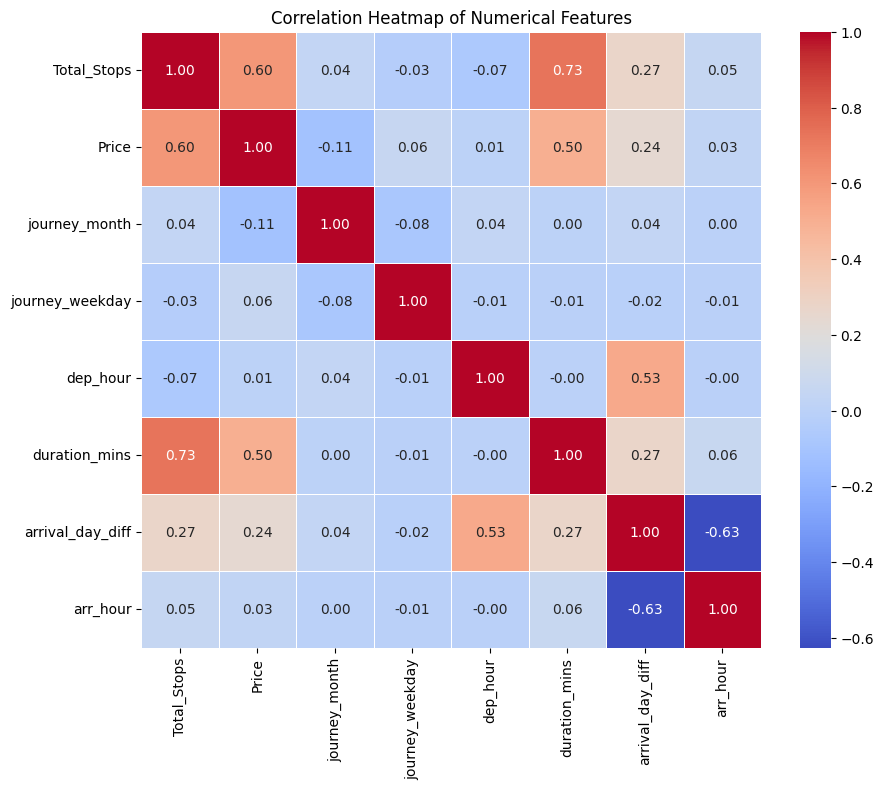

In [186]:
num_df = df.select_dtypes(include=["int64", "int32", "float64"])
corr = num_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

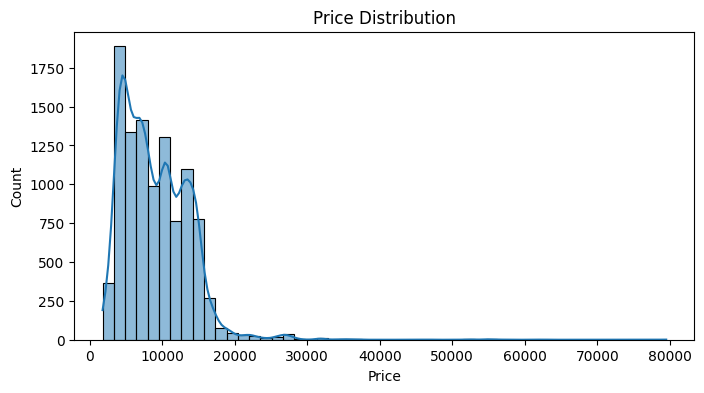

In [187]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Price"], bins=50, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

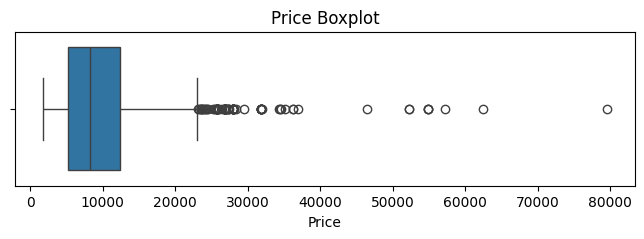

In [188]:
plt.figure(figsize=(8, 2))
sns.boxplot(x=df["Price"])
plt.title("Price Boxplot")
plt.show()


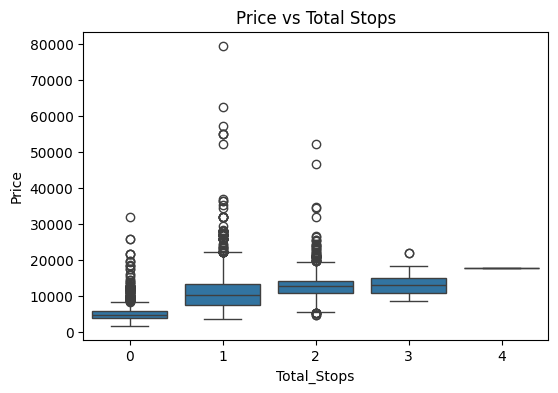

In [189]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="Total_Stops", y="Price", data=df)
plt.title("Price vs Total Stops")
plt.show()


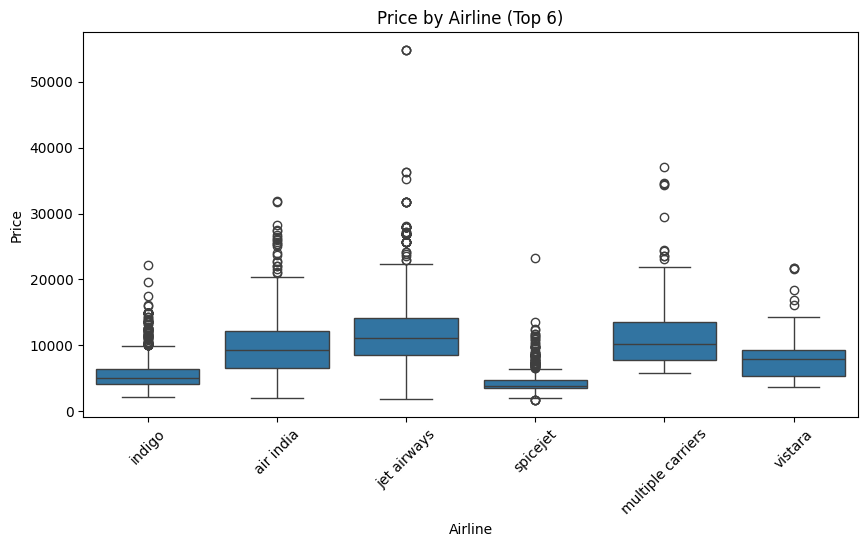

In [190]:
top_airlines = df["Airline"].value_counts().nlargest(6).index

plt.figure(figsize=(10, 5))
sns.boxplot(
    x="Airline",
    y="Price",
    data=df[df["Airline"].isin(top_airlines)]
)
plt.xticks(rotation=45)
plt.title("Price by Airline (Top 6)")
plt.show()


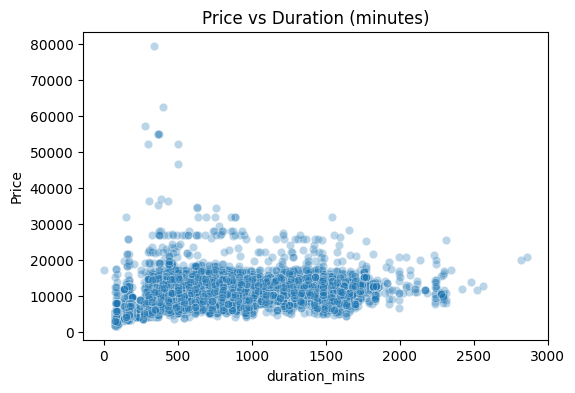

In [191]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x="duration_mins",
    y="Price",
    data=df,
    alpha=0.3
)
plt.title("Price vs Duration (minutes)")
plt.show()


In [192]:
df["Price_log"] = np.log1p(df["Price"])
df.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,journey_month,journey_weekday,dep_hour,duration_mins,arrival_day_diff,arr_hour,Price_log
0,indigo,banglore,new delhi,0,no info,3897,3,6,22,170,1,1,8.268219
1,air india,kolkata,banglore,2,no info,7662,5,2,5,445,0,13,8.944159
2,jet airways,delhi,cochin,2,no info,13882,6,6,9,1140,1,4,9.538420
3,indigo,kolkata,banglore,1,no info,6218,5,6,18,325,0,23,8.735364
4,indigo,banglore,new delhi,1,no info,13302,3,4,16,285,0,21,9.495745


In [193]:
df.to_csv(r"C:\flight_price_prediction\data\preprocessed\train_engineered.csv", index=False)

In [195]:


# target
y = df["Price_log"]

# features (drop both Price + Price_log)
X = df.drop(columns=["Price", "Price_log"], errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(8369, 11) (2093, 11) (8369,) (2093,)


In [196]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# identify column types
cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns

# numeric preprocessing
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# categorical preprocessing
cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# full preprocessing block
preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ]
)

preprocess


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [198]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# build full pipeline: preprocess -> model
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("regressor", LinearRegression())
])

# train
model.fit(X_train, y_train)

# predict
preds = model.predict(X_test)

# evaluate on log target
mae = mean_absolute_error(y_test, preds)
rmse = mean_squared_error(y_test, preds) ** 0.5

r2 = r2_score(y_test, preds)

print("On Price_log:")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


On Price_log:
MAE : 0.18874218584436
RMSE: 0.25440661722405605
R2  : 0.7560668543749813


In [199]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# build pipeline: preprocess -> ridge
ridge_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("regressor", Ridge(alpha=1.0))
])

# train
ridge_model.fit(X_train, y_train)

# predict
preds_ridge = ridge_model.predict(X_test)

# evaluate on log target
mae_ridge = mean_absolute_error(y_test, preds_ridge)
rmse_ridge = mean_squared_error(y_test, preds_ridge) ** 0.5
r2_ridge = r2_score(y_test, preds_ridge)

print("Ridge Regression on Price_log:")
print("MAE :", mae_ridge)
print("RMSE:", rmse_ridge)
print("R2  :", r2_ridge)


Ridge Regression on Price_log:
MAE : 0.1887332780302633
RMSE: 0.2543779947787554
R2  : 0.756121739506784


In [200]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("regressor", RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    ))
])

# train
rf_model.fit(X_train, y_train)

# predict
preds_rf = rf_model.predict(X_test)

# evaluate on log target
mae_rf = mean_absolute_error(y_test, preds_rf)
rmse_rf = mean_squared_error(y_test, preds_rf) ** 0.5
r2_rf = r2_score(y_test, preds_rf)

print("Random Forest on Price_log:")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)


Random Forest on Price_log:
MAE : 0.09776662514752278
RMSE: 0.17832642551678088
R2  : 0.8801479633491014


In [201]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gb_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("regressor", GradientBoostingRegressor(
        random_state=42
    ))
])

# train
gb_model.fit(X_train, y_train)

# predict
preds_gb = gb_model.predict(X_test)

# evaluate on log target
mae_gb = mean_absolute_error(y_test, preds_gb)
rmse_gb = mean_squared_error(y_test, preds_gb) ** 0.5
r2_gb = r2_score(y_test, preds_gb)

print("Gradient Boosting on Price_log:")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R2  :", r2_gb)


Gradient Boosting on Price_log:
MAE : 0.15339990426740369
RMSE: 0.2122996222867839
R2  : 0.8301316561496586


In [202]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "LinearRegression",
        "Ridge",
        "RandomForest",
        "GradientBoosting"
    ],
    "MAE_log": [
        mae,
        mae_ridge,
        mae_rf,
        mae_gb
    ],
    "RMSE_log": [
        rmse,
        rmse_ridge,
        rmse_rf,
        rmse_gb
    ],
    "R2_log": [
        r2,
        r2_ridge,
        r2_rf,
        r2_gb
    ]
})

# sort by best RMSE (lower is better)
results = results.sort_values("RMSE_log")
results


,Model,MAE_log,RMSE_log,R2_log
2,RandomForest,0.097767,0.178326,0.880148
3,GradientBoosting,0.153400,0.212300,0.830132
1,Ridge,0.188733,0.254378,0.756122
0,LinearRegression,0.188742,0.254407,0.756067
